In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [30]:
#checking for existance of file 
file_name=f'sales_data.csv'
if not os.path.exists(file_name):
    print(f'File: {file_name} Not Found')
    exit()
else:
    print(f'File: {file_name} Found')

File: sales_data.csv Found


In [31]:
#loading the dataset
df=pd.read_csv(file_name)
print("file loaded !")

file loaded !


In [32]:
#see the number of roes and columns
print(f'the shape of the dataset is (row,columns):{df.shape} \n')

the shape of the dataset is (row,columns):(50, 5) 



In [33]:
#see the 1st five values
print(f'\n first 5 rows are: \n{df.head()}')


 first 5 rows are: 
   Customer_ID   Age         City  Spending  Visits_Per_Month
0            1  25.0     New York     500.0               2.0
1            2  30.0  Los Angeles     700.0               NaN
2            3   NaN      Chicago     450.0               3.0
3            4  45.0      Chicago    1500.0              10.0
4            5  30.0     New York       NaN               5.0


In [34]:
#see last 5 values
print(f'\n last 5 rows are: \n{df.tail()}')


 last 5 rows are: 
    Customer_ID   Age         City  Spending  Visits_Per_Month
45           46  29.0     New York     620.0               3.0
46           47  53.0  Los Angeles    1700.0              10.0
47           48   NaN      Houston     810.0               4.0
48           49  27.0        Miami     530.0               2.0
49           50  32.0      Chicago     740.0               5.0


In [35]:
#seee what are the columns in dataset
df.columns

Index(['Customer_ID', 'Age', 'City', 'Spending', 'Visits_Per_Month'], dtype='str')

In [36]:
#see the datatypes of the columns it has
df.dtypes

Customer_ID           int64
Age                 float64
City                    str
Spending            float64
Visits_Per_Month    float64
dtype: object

In [37]:
#satistical summarry
print(df.describe())

       Customer_ID         Age     Spending  Visits_Per_Month
count     50.00000   45.000000    46.000000         49.000000
mean      25.50000   38.888889  1070.652174          4.816327
std       14.57738   19.292276  1025.246642          2.563148
min        1.00000   22.000000   300.000000          1.000000
25%       13.25000   29.000000   585.000000          3.000000
50%       25.50000   33.000000   815.000000          5.000000
75%       37.75000   44.000000  1187.500000          6.000000
max       50.00000  120.000000  6000.000000         10.000000


In [38]:
#see the information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       50 non-null     int64  
 1   Age               45 non-null     float64
 2   City              50 non-null     str    
 3   Spending          46 non-null     float64
 4   Visits_Per_Month  49 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 2.1 KB


In [39]:
# lookiing for null values
print(f"missing values\n{df.isnull().sum()}\n")

missing values
Customer_ID         0
Age                 5
City                0
Spending            4
Visits_Per_Month    1
dtype: int64



# handling the missing values

In [40]:

median_age=df['Age'].median()
print(f'meadian of age : {median_age}')

meadian of age : 33.0


In [41]:
#filling null values with median
df['Age']=df['Age'].fillna(median_age)

In [42]:
#filling the null values by mean
df['Spending']=df['Spending'].fillna(df["Spending"].mean())

In [43]:
#fill9ing the null values by mode
df['Visits_Per_Month']=df['Visits_Per_Month'].fillna(df["Visits_Per_Month"].mode()[0])

In [44]:
#verify the handling of missing values
df.isna().sum()

Customer_ID         0
Age                 0
City                0
Spending            0
Visits_Per_Month    0
dtype: int64

In [45]:
#checking for the duplicated data
df.duplicated().sum()


np.int64(0)

In [46]:
#delete duplicates if exists
df.drop_duplicates()

,Customer_ID,Age,City,Spending,Visits_Per_Month
0,1,25.0,New York,500.000000,2.0
1,2,30.0,Los Angeles,700.000000,5.0
2,3,33.0,Chicago,450.000000,3.0
3,4,45.0,Chicago,1500.000000,10.0
4,5,30.0,New York,1070.652174,5.0
5,6,22.0,Los Angeles,600.000000,2.0
6,7,120.0,New York,5000.000000,1.0
7,8,35.0,Houston,800.000000,4.0
8,9,28.0,Miami,300.000000,1.0
9,10,50.0,Chicago,1200.000000,8.0


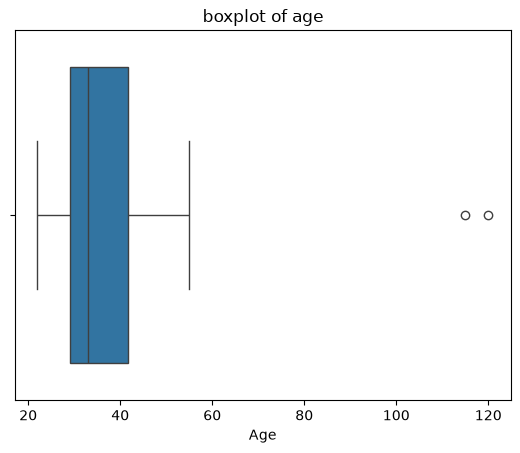

In [49]:
#box plot to detect outliers
sns.boxplot(x=df['Age'])
plt.title('boxplot of age')
plt.show()

In [ ]:
#detecting the outliers with iqr method.
q3=df['Age'].quantile(0.75)
q1=df['Age'].quantile(0.25)
iqr=q3-q1
ub=q3+1.5*iqr
lb=q1-1.5*iqr
outliers=df[(df['Age']>ub) | (df['Age']<lb)]
print(outliers)


    Customer_ID    Age      City  Spending  Visits_Per_Month
6             7  120.0  New York    5000.0               1.0
27           28  115.0   Houston    6000.0               1.0


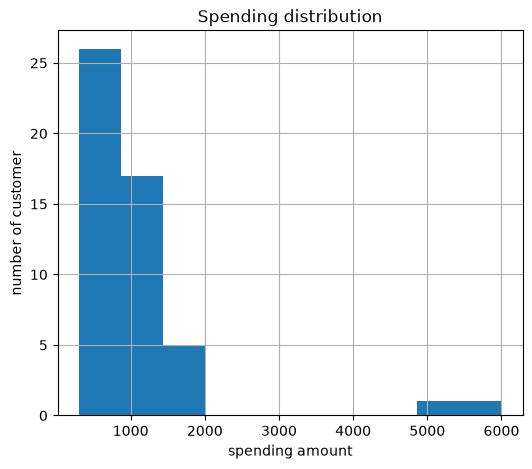

In [65]:
#distribution of data
plt.figure(figsize=(6,5))
plt.title("Spending distribution")
df['Spending'].hist(bins=10)
plt.xlabel('spending amount')
plt.ylabel('number of customer')
plt.show()

In [ ]:
#correlation matrix
corr=df.corr(numeric_only=True)
print(corr)

                  Customer_ID       Age  Spending  Visits_Per_Month
Customer_ID          1.000000 -0.066118 -0.042168          0.136026
Age                 -0.066118  1.000000  0.962251          0.114171
Spending            -0.042168  0.962251  1.000000          0.026477
Visits_Per_Month     0.136026  0.114171  0.026477          1.000000


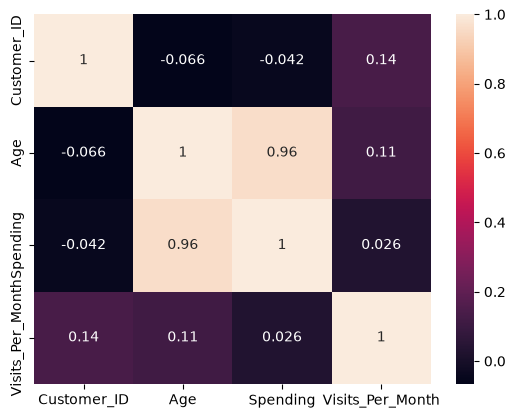

In [67]:
#heatmap to visualize correlation
sns.heatmap(corr,annot=True)
plt.show()

# Data visualization

(array([19., 18.,  8.,  3.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([ 22. ,  31.8,  41.6,  51.4,  61.2,  71. ,  80.8,  90.6, 100.4,
        110.2, 120. ]),
 <BarContainer object of 10 artists>)

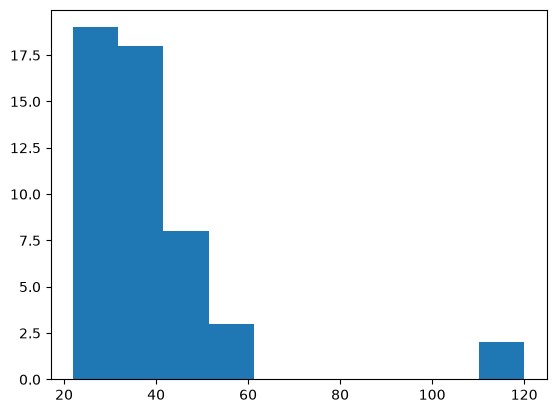

In [70]:
plt.hist(df['Age'])

<Axes: xlabel='City', ylabel='city count'>

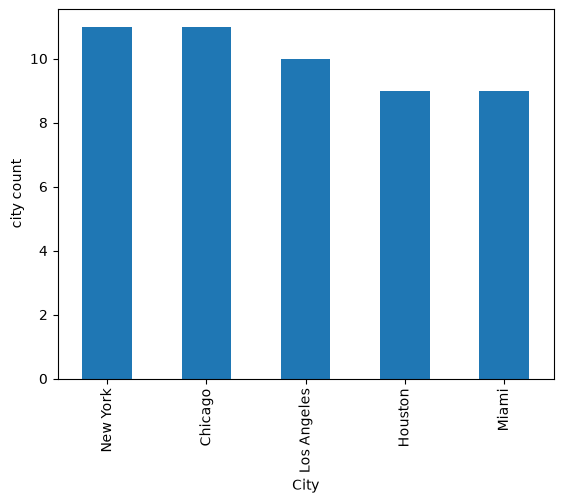

In [74]:
df['City'].value_counts().plot(kind='bar',xlabel='City',ylabel='city count')

<Axes: >

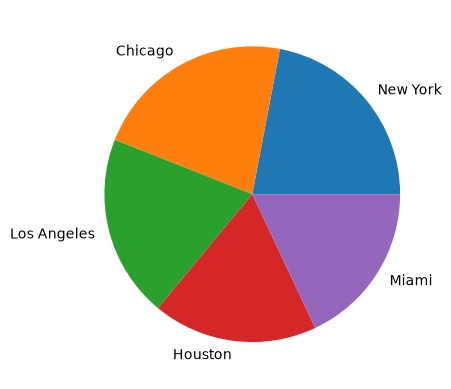

In [81]:
df['City'].value_counts().plot(kind='pie')

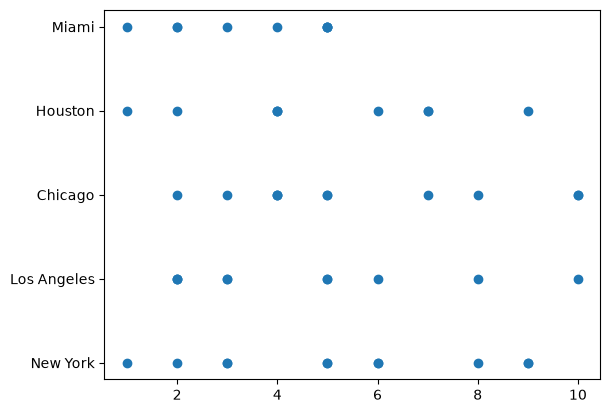

In [83]:
plt.scatter(y=df['City'],x=df['Visits_Per_Month'])

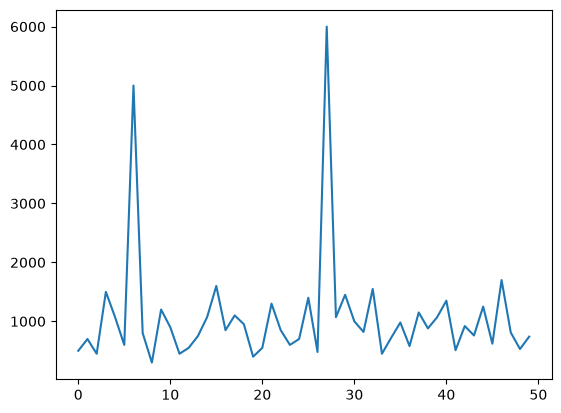

In [91]:
plt.plot(df['Spending'])

In [93]:
#checking the skewness
df.skew(numeric_only=True)

Customer_ID         0.000000
Age                 3.365957
Spending            3.988004
Visits_Per_Month    0.499402
dtype: float64